In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data=pd.read_csv('cluster_data.csv')
data

,Feature 1,Feature 2
0,2.698582,-0.672960
1,-0.128113,4.355952
2,2.509049,5.773146
3,-1.518276,3.444886
4,-0.072283,2.883769
...,...,...
495,10.303693,-4.378493
496,-0.730000,6.254563
497,-3.478708,2.257991
498,-2.081214,2.447245


In [4]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature 1  500 non-null    float64
 1   Feature 2  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


,Feature 1,Feature 2
count,500.000000,500.000000
mean,1.831353,2.694970
std,4.086149,3.494165
min,-3.896491,-4.378493
25%,-1.174033,0.200712
50%,0.604212,2.807746
75%,2.750212,5.132506
max,11.867680,10.216205


In [5]:
X = np.array(data)



In [6]:
X.shape

(500, 2)

In [7]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X_scaled = (X - X_mean) / X_std


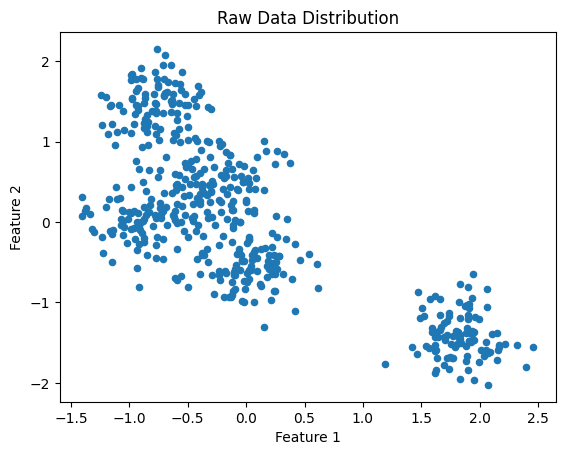

In [8]:


plt.scatter(X_scaled[:,0], X_scaled[:,1], s=20)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Raw Data Distribution")
plt.show()


In [9]:


def initialize_centroids(X, K):
    np.random.seed(42)
    indices = np.random.choice(len(X), K, replace=False)
    return X[indices]


In [10]:
def assign_clusters(X, centroids):
    labels = []
    for x in X:
        distances = np.sum((centroids - x) ** 2, axis=1)
        labels.append(np.argmin(distances))
    return np.array(labels)


In [11]:
def update_centroids(X, labels, K):
    centroids = []
    for k in range(K):
        cluster_points = X[labels == k]
        centroids.append(cluster_points.mean(axis=0))
    return np.array(centroids)


In [12]:
def k_means(X, K, max_iters=100):
    centroids = initialize_centroids(X, K)

    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, K)

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return centroids, labels


In [13]:
def compute_wcss(X, centroids, labels):
    total = 0
    for i, x in enumerate(X):
        total += np.sum((x - centroids[labels[i]]) ** 2)
    return total


In [14]:
K_range = range(1, 11)
wcss_values = []

for K in K_range:
    centroids, labels = k_means(X, K)
    wcss = compute_wcss(X, centroids, labels)
    wcss_values.append(wcss)


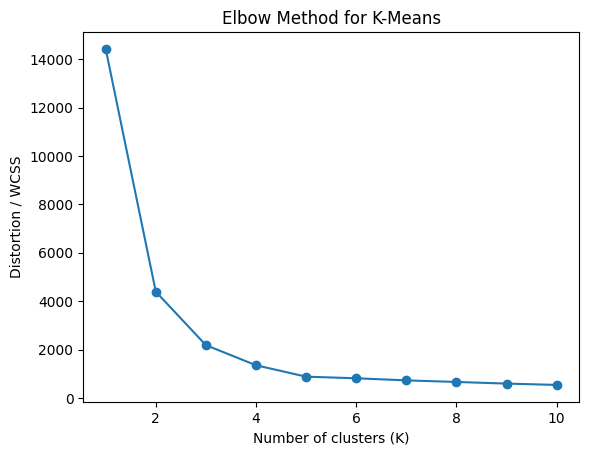

In [15]:
plt.plot(K_range, wcss_values, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Distortion / WCSS")
plt.title("Elbow Method for K-Means")
plt.show()


In [16]:
K = 4 
centroids, labels = k_means(X, K)


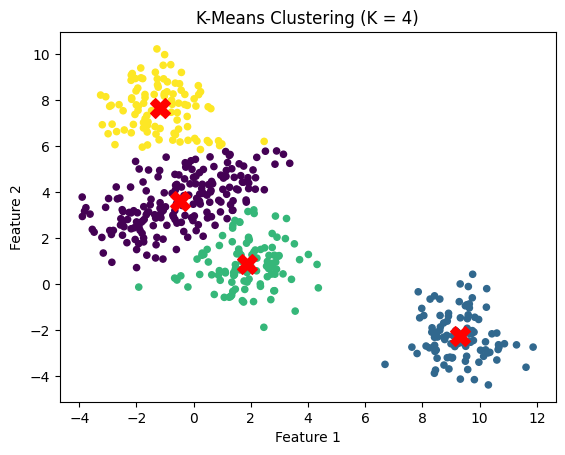

In [17]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=labels, s=20)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200)

plt.title("K-Means Clustering (K = 4)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
